# The Wyckoff Method -- a quantitative teardown
### Real daily tape - up to 33 years - volume-confirmed Spring/Upthrust - HAC inference - coin placebo - per-leg split

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Phases_detectable%3F: Not_Supported](https://img.shields.io/badge/Phases_detectable%3F-Not_Supported-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim carrying its standard error.* We mechanise the Wyckoff Spring (accumulation buy) and Upthrust (distribution sell) as volume-confirmed events inside a ZigZag-bracketed trading range, and test whether they predict the forward move on eight liquid index/ETF tapes.

> **Not investment advice.** Real data: Yahoo auto-adjusted daily OHLCV, 8 tapes, as-of 2026-06-24; reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **In plain words** notes translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from wyckoff_method import data, strategy as st

BASKET = data.load_basket()           # cache-first; {} if no cache present
HAVE_REAL = len(BASKET) >= 4

def pooled(horizon, cost=0.0, vol_confirm=True, pct=0.05, coin=False, seed=446, col="ret_gross"):
    """Pool Spring/Upthrust trades across the cached basket."""
    leds = []
    for tk, b in BASKET.items():
        ev = st.find_events(b, pct=pct, vol_confirm=vol_confirm)
        if coin:
            dirs = st.random_directions(len(ev), seed=seed)
            leds.append(st.run_trades(b, ev, horizon, cost_bps=cost, directions=dirs))
        else:
            leds.append(st.run_trades(b, ev, horizon, cost_bps=cost))
    return pd.concat(leds, ignore_index=True) if leds else pd.DataFrame()

print("real daily cache present:", HAVE_REAL, "| tapes:", list(BASKET.keys()))


real daily cache present: True | tapes: ['SPY', 'QQQ', 'DIA', 'IWM', 'GLD', 'XLE', 'EEM', 'TLT']


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Combined signal best gross **+44 bps** (20d), HAC *t* = **0.89**; a coin at the same bars earns more (+53); placebo *p* >= 0.13. Spring leg *t* = 2.29 **fails HAC (1.77)**, Upthrust leg negative. |
| **Tradability** | `MIRAGE` | No edge to charge costs against; net combined *t* ≈ 1.0, coin sits above it at every cost. |
| **Phases detectable?** | `NOT SUPPORTED` | Events fire (404 of them) but don't foretell the move; the volume tell *subtracts* signal (no-filter *t* = 1.98 > with-filter 1.11). Synthetic control lights up at *t* = 5.20 -> a true negative. |

> In plain words: the two famous events happen all the time, but they don't predict anything once you respect autocorrelation and compare to a coin. The only positive leg is the long side in a bull-market sample.

## 1 - The claim, steelmanned

Let a trading range have support $S$ and resistance $R$. Wyckoff asserts:

- **H1 (Spring).** A bar $t$ with $\mathrm{low}_t < S$ but $\mathrm{close}_t > S$, on volume below its trailing average, predicts **positive** forward returns (the markup): $\mathbb{E}[r_{t+1,t+h}\mid \text{Spring}] > 0$.
- **H2 (Upthrust).** A bar with $\mathrm{high}_t > R$ but $\mathrm{close}_t < R$ on weak volume predicts **negative** forward returns (the markdown).
- **H3 (the volume tell).** Conditioning on *below-average* volume sharpens the signal vs not conditioning on volume at all.

We **fail to reject zero** for the combined long-short (HAC *t* = 0.89 at 20d). H1's long leg is positive raw (*t* = 2.29) but **fails HAC (1.77)** and is confounded with market drift; H2 is **rejected** (the short leg is *positive*-return-losing, mean -56 bps); H3 is **rejected** -- removing the volume filter *raises* the *t* to 1.98.

## 2 - So what?

Wyckoff is taught in nearly every serious chart-reading curriculum and underpins a large coaching industry. If H1+H2 held, it would be a rare TA method that pays on **both** the long and short legs -- a genuine read on order flow, consistent with the over-reaction literature (De Bondt-Thaler 1985) at the multi-week horizon. The interesting failure mode is exactly the one we find: the *buy* leg looks alive while the *sell* leg loses, which is the fingerprint of a directional-drift artefact, not a phase detector.

## 3 - How we'd know -- the protocol

- **Range.** 5% ZigZag pivots; a window of 4 consecutive pivots inside a <=20%-wide band defines a range (support = lowest pivot low, resistance = highest pivot high). The range is 'ready' only at its last pivot's **confirmation bar** (look-ahead-free).
- **Event.** In the 30 bars after a range is ready: a **Spring** (low < S, close > S) or **Upthrust** (high > R, close < R), with the event bar's volume **below** its trailing 20-day average (the Wyckoff tell). First qualifying event per range.
- **Entry.** One day after the event bar (it's fully known on its own close); hold 5/10/20/40 days. Direction: +1 Spring, -1 Upthrust.
- **Inference.** One-sample *t* and Newey-West HAC *t* vs 0.
- **Placebo.** Same event bars, random +/-1 direction, 20,000 draws -- does the *label* beat a coin?
- **Controls.** Per-leg split; volume-filter on/off; ZigZag 3/5/8%; cost sweep; a synthetic tape with a *planted* markup (the faithful-engine positive control).

Eight tapes: SPY, QQQ, DIA, IWM, GLD, XLE, EEM, TLT -- daily, as-of 2026-06-24.

## 4 - The teardown

### 4a - Combined signal vs coin, with placebo p-values, across horizons

Gross per-trade mean and HAC *t*, the same-bars coin control, and the label-shuffle placebo *p* at each horizon.

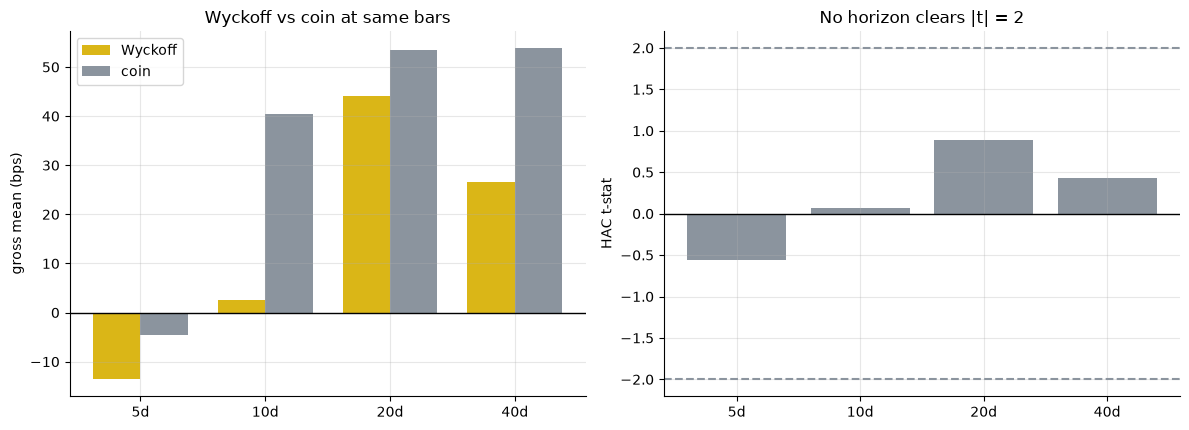

 h   n   win%  mean_bps      t  hac_t  coin_bps  placebo_p
 5 404 45.545   -13.603 -0.655 -0.565    -4.645      0.744
10 404 52.228     2.623  0.084  0.071    40.438      0.463
20 404 53.465    44.135  1.115  0.895    53.408      0.130
40 404 50.990    26.583  0.502  0.424    53.894      0.303


In [2]:
H = [5,10,20,40]
if HAVE_REAL:
    rows = []
    for h in H:
        led = pooled(h, 0., True)
        s = st.summarize(led, 'ret_gross')
        c = st.summarize(pooled(h, 0., True, coin=True), 'ret_gross')
        # pooled label-shuffle placebo
        obs = led['ret_gross'].mean(); mags = led['ret_gross'].to_numpy()*led['dir'].to_numpy()
        rng = np.random.default_rng(446)
        draws = np.array([(rng.choice([-1,1],size=len(mags))*mags).mean() for _ in range(20000)])
        rows.append((h, s['n_trades'], s['win_rate']*100, s['mean_bps'], s['t'],
                     s['hac_t'], c['mean_bps'], float((draws>=obs).mean())))
    tab = pd.DataFrame(rows, columns=['h','n','win%','mean_bps','t','hac_t','coin_bps','placebo_p'])
else:
    tab = pd.DataFrame({'h':H,'n':[404]*4,'win%':[45.5,52.2,53.5,51.0],
        'mean_bps':[-13.60,2.62,44.14,26.58],'t':[-0.65,0.08,1.11,0.50],
        'hac_t':[-0.56,0.07,0.89,0.42],'coin_bps':[-4.64,40.44,53.41,53.89],
        'placebo_p':[0.7440,0.4630,0.1296,0.3034]})

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
x = range(len(H)); w=.38
axes[0].bar([i-w/2 for i in x], tab['mean_bps'], width=w, color=AMBER, label='Wyckoff')
axes[0].bar([i+w/2 for i in x], tab['coin_bps'], width=w, color=GREY, label='coin')
axes[0].axhline(0,c='k',lw=1); axes[0].set_xticks(list(x)); axes[0].set_xticklabels([f'{h}d' for h in H])
axes[0].set_ylabel('gross mean (bps)'); axes[0].set_title('Wyckoff vs coin at same bars'); axes[0].legend()
axes[1].bar([f'{h}d' for h in H], tab['hac_t'], color=[GREEN if abs(t)>=2 else GREY for t in tab['hac_t']])
axes[1].axhline(2,ls='--',c=GREY); axes[1].axhline(-2,ls='--',c=GREY); axes[1].axhline(0,c='k',lw=1)
axes[1].set_ylabel('HAC t-stat'); axes[1].set_title('No horizon clears |t| = 2')
plt.tight_layout(); plt.show()
print(tab.round(3).to_string(index=False))

> In plain words: the best HAC *t* is **0.89** (20-day) -- well short of 2 -- and at every horizon a coin at the identical bars is competitive or better. The placebo *p* bottoms out at **0.13**: the Spring/Upthrust *label* carries no directional information over a coin.

### 4b - The per-leg split -- the bull-market tell

A real phase detector pays on both legs. Here, only the long (Spring) leg is positive -- and the short (Upthrust) leg loses -- in a sample where the underlyings drifted up.

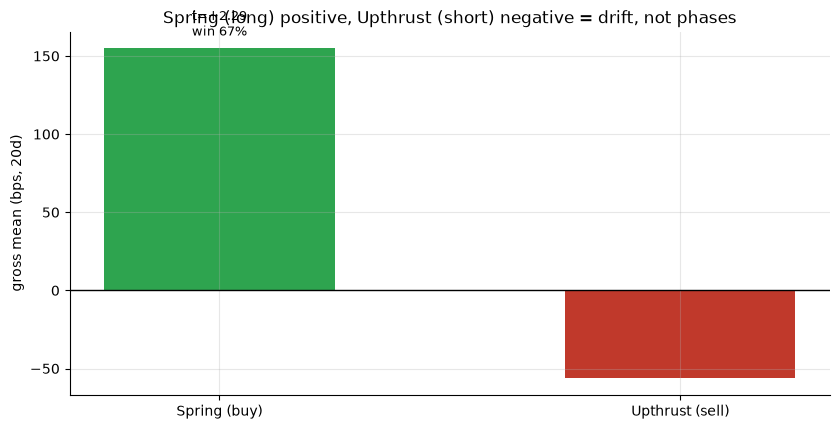

                   n   win%  mean_bps     t  hac_t
Spring (buy)     192  66.67    155.08  2.29   1.77
Upthrust (sell)  212  41.51    -56.35 -1.31  -1.23


In [3]:
if HAVE_REAL:
    led = pooled(20, 0., True)
    sp = st.summarize(led[led['kind']=='spring'], 'ret_gross')
    up = st.summarize(led[led['kind']=='upthrust'], 'ret_gross')
    vals = [(sp['n_trades'],sp['win_rate']*100,sp['mean_bps'],sp['t'],sp['hac_t']),
            (up['n_trades'],up['win_rate']*100,up['mean_bps'],up['t'],up['hac_t'])]
else:
    vals = [(192,66.7,155.08,2.29,1.77),(212,41.5,-56.35,-1.31,-1.23)]
leg = pd.DataFrame(vals, index=['Spring (buy)','Upthrust (sell)'],
                   columns=['n','win%','mean_bps','t','hac_t'])

fig, ax = plt.subplots(figsize=(8.5,4.4))
bars = ax.bar(leg.index, leg['mean_bps'], color=[GREEN, RED], width=.5)
ax.axhline(0,c='k',lw=1); ax.set_ylabel('gross mean (bps, 20d)')
ax.set_title('Spring (long) positive, Upthrust (short) negative = drift, not phases')
for b,(_,row) in zip(bars, leg.iterrows()):
    ax.annotate(f"t={row['t']:+.2f}\nwin {row['win%']:.0f}%",
        (b.get_x()+b.get_width()/2, b.get_height()+(8 if b.get_height()>=0 else -22)),
        ha='center', fontsize=9)
plt.tight_layout(); plt.show()
print(leg.round(2).to_string())

> In plain words: the Spring's one-sample *t* = 2.29 looks promising but its HAC *t* is only **1.77** (below 2), and the Upthrust short leg *loses* (-56 bps). A genuine accumulation/distribution detector is symmetric; this is a long position dressed up as one.

### 4c - The volume tell adds nothing (H3 rejected)

Wyckoff rests on volume: the break 'should' follow through but doesn't, *because volume is light*. If that tell mattered, conditioning on below-average volume would sharpen the signal. It does the opposite.

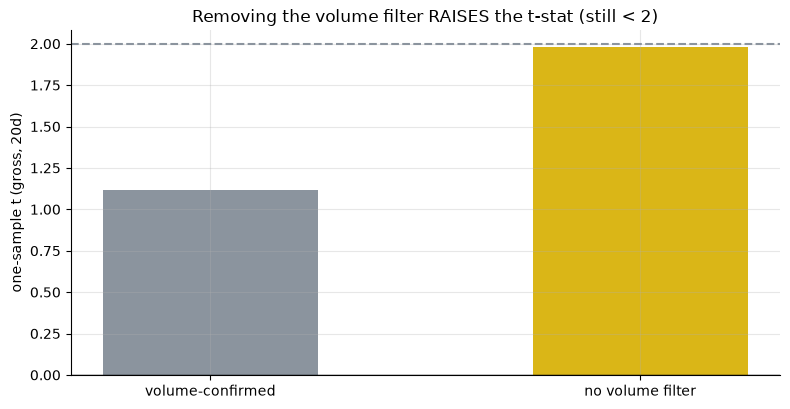

                    n  mean_bps     t  hac_t
volume-confirmed  404     44.14  1.11   0.89
no volume filter  615     63.33  1.98   1.60


In [4]:
if HAVE_REAL:
    vc = st.summarize(pooled(20, 0., True), 'ret_gross')
    nv = st.summarize(pooled(20, 0., False), 'ret_gross')
    vals = [(vc['n_trades'],vc['mean_bps'],vc['t'],vc['hac_t']),
            (nv['n_trades'],nv['mean_bps'],nv['t'],nv['hac_t'])]
else:
    vals = [(404,44.14,1.11,0.89),(615,63.33,1.98,1.60)]
vf = pd.DataFrame(vals, index=['volume-confirmed','no volume filter'],
                  columns=['n','mean_bps','t','hac_t'])
fig, ax = plt.subplots(figsize=(8.0,4.2))
ax.bar(vf.index, vf['t'], color=[GREY, AMBER], width=.5)
ax.axhline(2, ls='--', c=GREY); ax.axhline(0,c='k',lw=1)
ax.set_ylabel('one-sample t (gross, 20d)')
ax.set_title('Removing the volume filter RAISES the t-stat (still < 2)')
plt.tight_layout(); plt.show()
print(vf.round(2).to_string())

> In plain words: the low-volume condition that's supposed to be the method's lie-detector actually *removes* return -- the unfiltered version reaches *t* = 1.98 (its closest brush with significance), and even that misses 2. The volume tell is not adding information here.

### 4d - Robustness: the ZigZag threshold

The whole thing hinges on what counts as a 'swing'. Vary the ZigZag percentage and the (already absent) effect doesn't stabilise -- it swings from exactly zero to noisy-positive on a handful of events.

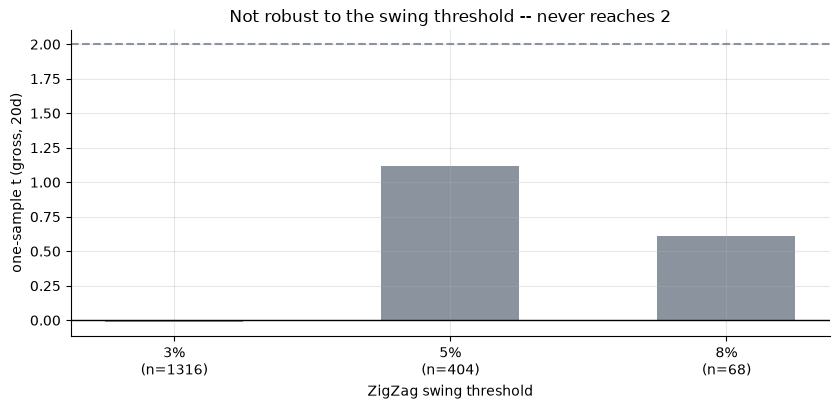

 pct    n  mean_bps      t  hac_t
0.03 1316    -0.211 -0.011 -0.009
0.05  404    44.135  1.115  0.895
0.08   68    70.606  0.611  0.507


In [5]:
if HAVE_REAL:
    pr = []
    for p in (0.03,0.05,0.08):
        s = st.summarize(pooled(20, 0., True, pct=p), 'ret_gross')
        pr.append((p, s['n_trades'], s['mean_bps'], s['t'], s['hac_t']))
    pt = pd.DataFrame(pr, columns=['pct','n','mean_bps','t','hac_t'])
else:
    pt = pd.DataFrame({'pct':[0.03,0.05,0.08],'n':[1316,404,68],
        'mean_bps':[-0.21,44.14,70.61],'t':[-0.01,1.11,0.61],'hac_t':[-0.01,0.89,0.51]})
fig, ax = plt.subplots(figsize=(8.5,4.2))
ax.bar([f'{p:.0%}\n(n={n})' for p,n in zip(pt['pct'],pt['n'])], pt['t'],
       color=GREY, width=.5)
ax.axhline(2,ls='--',c=GREY); ax.axhline(0,c='k',lw=1)
ax.set_ylabel('one-sample t (gross, 20d)'); ax.set_xlabel('ZigZag swing threshold')
ax.set_title('Not robust to the swing threshold -- never reaches 2')
plt.tight_layout(); plt.show()
print(pt.round(3).to_string(index=False))

> In plain words: a tighter 3% ZigZag fires 1,316 events for a mean of essentially **zero**; a looser 8% fires only 68. There's no threshold where a stable, significant edge appears.

### 4e - The positive control -- the engine works when we plant a markup

Does the detector even work? On a synthetic tape where we *plant* a real markup after the Spring (and markdown after the Upthrust), it should light up; on a quiet random walk it should not.

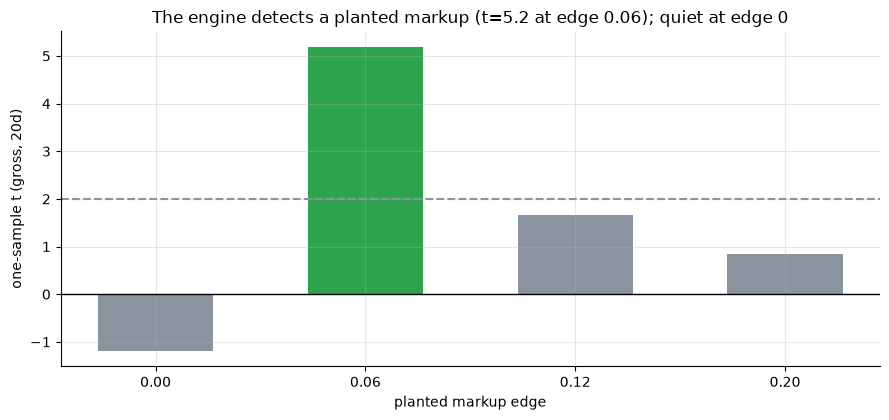

 edge  n  win%  mean_bps     t  hac_t
 0.00  7 42.86    -78.13 -1.20  -1.61
 0.06 93 68.82    233.22  5.20   4.62
 0.12 71 47.89    132.00  1.67   1.68
 0.20 26 46.15    253.17  0.83   1.13


In [6]:
edges = [0.0, 0.06, 0.12, 0.20]
syn = []
for e in edges:
    sb, truth = data.synthetic_panel(edge=e)
    ev = st.find_events(sb, vol_confirm=True)
    s = st.summarize(st.run_trades(sb, ev, 20, cost_bps=0.0), 'ret_gross')
    syn.append((e, s['n_trades'], s['win_rate']*100, s['mean_bps'], s['t'], s['hac_t']))
syn = pd.DataFrame(syn, columns=['edge','n','win%','mean_bps','t','hac_t'])

fig, ax = plt.subplots(figsize=(9.0,4.3))
ax.bar([f'{e:.2f}' for e in syn['edge']], syn['t'],
       color=[GREEN if abs(t)>=2 else GREY for t in syn['t']], width=.55)
ax.axhline(2,ls='--',c=GREY); ax.axhline(0,c='k',lw=1)
ax.set_xlabel('planted markup edge'); ax.set_ylabel('one-sample t (gross, 20d)')
ax.set_title('The engine detects a planted markup (t=5.2 at edge 0.06); quiet at edge 0')
plt.tight_layout(); plt.show()
print(syn.round(2).to_string(index=False))

> In plain words: at edge 0 the detector is quiet (|*t*| < 2, only 7 noise events); at a modest planted edge it lights up at *t* = **5.20**. (At very large edges the markup outruns the 20-day hold and disrupts the next range, so *n* and *t* fall -- a quirk of the toy generator.) The harness **would** catch real accumulation/distribution -- the real tape simply has none to catch.

## 5 - The verdict

- **Signal `NONE`** -- 404 events, best combined HAC *t* = 0.89, beaten by a coin at the same bars; placebo *p* >= 0.13. The Spring leg (*t* = 2.29) fails HAC (1.77) and is the bull-market long bias; the Upthrust short leg loses.
- **Tradability `MIRAGE`** -- no edge to deploy; net combined *t* ≈ 1.0 and the coin outperforms at every cost level.
- **Phases detectable? `NOT SUPPORTED`** -- events fire but don't predict the move, and the volume tell *subtracts* signal (no-filter *t* = 1.98 > with-filter 1.11). The synthetic control (*t* = 5.20) proves this is a true negative.

## 6 - Could you trade it? -- cost sweep

Events are infrequent so costs barely move the number -- but there's nothing to erode. The coin sits above the Wyckoff signal at every cost level.

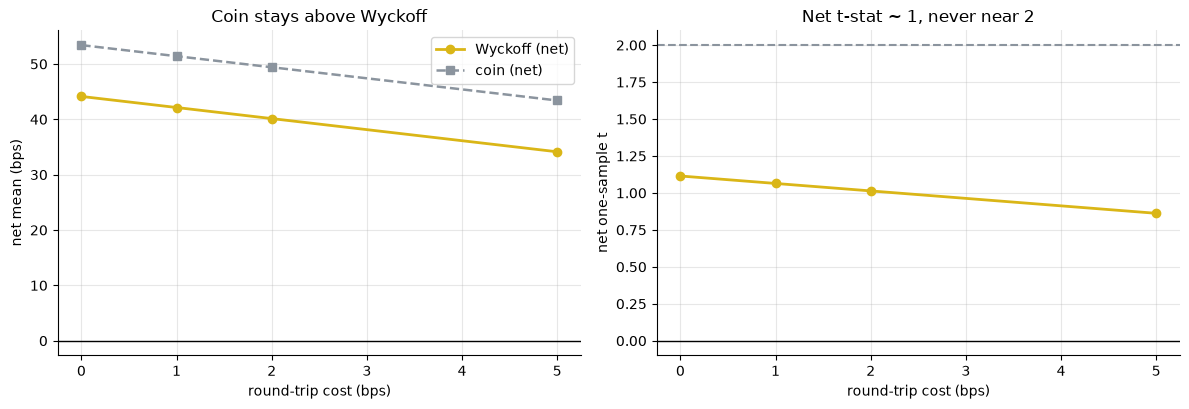

net mean by cost: [44.1, 42.1, 40.1, 34.1]


In [7]:
costs = [0.,1.,2.,5.]
if HAVE_REAL:
    net = [st.summarize(pooled(20, c, True), 'ret_net')['mean_bps'] for c in costs]
    nett = [st.summarize(pooled(20, c, True), 'ret_net')['t'] for c in costs]
    coin_net = [st.summarize(pooled(20, c, True, coin=True), 'ret_net')['mean_bps'] for c in costs]
else:
    net = [44.14,42.14,40.14,34.14]; nett=[1.11,1.06,1.01,0.86]
    coin_net=[53.41,51.41,49.41,43.41]
fig, axes = plt.subplots(1,2,figsize=(12,4.2))
axes[0].plot(costs, net, 'o-', c=AMBER, lw=2, label='Wyckoff (net)')
axes[0].plot(costs, coin_net, 's--', c=GREY, lw=1.8, label='coin (net)')
axes[0].axhline(0,c='k',lw=1); axes[0].set_xlabel('round-trip cost (bps)')
axes[0].set_ylabel('net mean (bps)'); axes[0].set_title('Coin stays above Wyckoff'); axes[0].legend()
axes[1].plot(costs, nett, 'o-', c=AMBER, lw=2)
axes[1].axhline(2,ls='--',c=GREY); axes[1].axhline(0,c='k',lw=1)
axes[1].set_xlabel('round-trip cost (bps)'); axes[1].set_ylabel('net one-sample t')
axes[1].set_title('Net t-stat ~ 1, never near 2')
plt.tight_layout(); plt.show()
print('net mean by cost:', [round(x,1) for x in net])

> In plain words: this isn't 'a real edge that costs kill' -- it's no edge at all. The Mirage stamp is about the *absence* of a signal, not its erosion.

## 7 - Going further -- the positive control and open questions

The synthetic control confirms the engine is a faithful Spring/Upthrust detector (*t* = 5.20 on a planted markup). The real-market answer is a clean negative. Forks worth pursuing:

- **Market-neutral legs.** Subtract the index return over the same window so the bull-market drift cancels, then re-test whether the Spring beats the Upthrust. If a symmetric residual survives at HAC *t* > 2, Wyckoff has genuine support.
- **Bear-regime sub-sample (2008, 2022).** The Upthrust short leg should *work* in a down-trending regime if it's a real distribution detector rather than a losing short in a bull market.
- **Richer event definitions.** A real Selling Climax / Buying Climax bar (effort-vs-result: huge volume, small range, then reversal) instead of the minimal low/high-pierce-and-recover rule.
- **The siblings.** [Study 445 -- Elliott Wave](../../445-elliott-wave/) and [Study 444 -- Dow Theory](../../444-dow-theory/) -- the same mechanical-proxy method on the other irreducibly-subjective classics.